# KMeans v2 — CWRU by_severity — Comparaison exp_083 vs exp_091

| Champ | Valeur |
|-------|--------|
| **Expérience ancienne** | exp_083 — K=2 fixe, seuil cross-tâche |
| **Expérience nouvelle** | exp_091 — K=silhouette, seuil par tâche |
| **Scénario** | by_severity : 0.007'' → 0.014'' → 0.021'' (3 tâches) |
| **Sprint** | 13 — analyse paramètres non supervisés CWRU |

In [1]:
import json, os, sys
from pathlib import Path
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display

_cwd = Path('.').resolve()
if _cwd.name == 'cwru_by_severity': os.chdir(_cwd.parent.parent.parent)
elif _cwd.name == 'cl_eval': os.chdir(_cwd.parent.parent)
elif _cwd.name == 'notebooks': os.chdir(_cwd.parent)
REPO_ROOT = Path('.').resolve()
if str(REPO_ROOT) not in sys.path: sys.path.insert(0, str(REPO_ROOT))

OLD_DIR = REPO_ROOT / 'experiments/exp_083_kmeans_cwru_by_severity/results'
NEW_DIR = REPO_ROOT / 'experiments/exp_091_kmeans_cwru_by_severity_v2/results'
FIGURES_DIR = REPO_ROOT / 'notebooks/figures/cl_evaluation/kmeans/cwru/by_severity_v2'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

TASK_NAMES = ['0.007"', '0.014"', '0.021"']

old = json.loads((OLD_DIR / 'metrics_cl.json').read_text())
new = json.loads((NEW_DIR / 'metrics_cl.json').read_text())
print('Chargement OK')

Chargement OK


In [2]:
# Section 2 — Comparaison métriques CL

table = f"""
| Métrique | exp_083 (K=2 fixe, seuil cross-tâche) | exp_091 (K=silhouette, seuil par tâche) | Delta |
|----------|-----------------------------------------|-----------------------------------------|-------|
| **AA (avg accuracy)** | {old['acc_final']:.4f} | {new['acc_final']:.4f} | {new['acc_final']-old['acc_final']:+.4f} |
| **AF (avg forgetting)** | {old['avg_forgetting']:.4f} | {new['avg_forgetting']:.4f} | {new['avg_forgetting']-old['avg_forgetting']:+.4f} |
| **BWT** | {old['backward_transfer']:+.4f} | {new['backward_transfer']:+.4f} | {new['backward_transfer']-old['backward_transfer']:+.4f} |
| **RAM peak** | {old['ram_peak_bytes']:,} B | {new['ram_peak_bytes']:,} B | — |
| **K sélectionné (tâche 0)** | 2 (fixe) | {new['k_selected_per_task'][0]} (silhouette) | — |
| **K sélectionné (tâche 1)** | 2 (fixe) | {new['k_selected_per_task'][1]} (silhouette) | — |
| **K sélectionné (tâche 2)** | 2 (fixe) | {new['k_selected_per_task'][2]} (silhouette) | — |
"""
display(Markdown(table))

print('\nSeuils par tâche (exp_091):')
for k, v in new['thresholds_per_task'].items():
    print(f'  Task {k} ({TASK_NAMES[int(k)]}): {v:.4f}')


| Métrique | exp_083 (K=2 fixe, seuil cross-tâche) | exp_091 (K=silhouette, seuil par tâche) | Delta |
|----------|-----------------------------------------|-----------------------------------------|-------|
| **AA (avg accuracy)** | 0.3030 | 0.4502 | +0.1472 |
| **AF (avg forgetting)** | 0.0649 | 0.0000 | -0.0649 |
| **BWT** | +0.2857 | +0.5065 | +0.2208 |
| **RAM peak** | 5,432 B | 5,340 B | — |
| **K sélectionné (tâche 0)** | 2 (fixe) | 2 (silhouette) | — |
| **K sélectionné (tâche 1)** | 2 (fixe) | 2 (silhouette) | — |
| **K sélectionné (tâche 2)** | 2 (fixe) | 2 (silhouette) | — |



Seuils par tâche (exp_091):
  Task 0 (0.007"): 2.8547
  Task 1 (0.014"): 3.2919
  Task 2 (0.021"): 4.2624


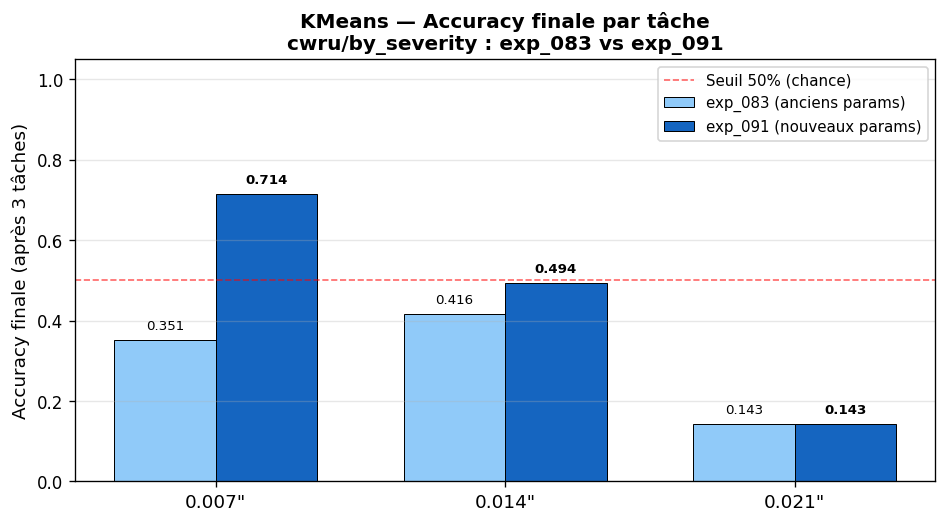

In [3]:
x = np.arange(len(TASK_NAMES))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 4.5))
bars_old = ax.bar(x - width/2, old['per_task_acc'], width, label='exp_083 (anciens params)', color='#90CAF9', edgecolor='black', linewidth=0.6)
bars_new = ax.bar(x + width/2, new['per_task_acc'], width, label='exp_091 (nouveaux params)', color='#1565C0', edgecolor='black', linewidth=0.6)

ax.axhline(y=0.5, color='red', linestyle='--', linewidth=1, alpha=0.6, label='Seuil 50% (chance)')
ax.set_xticks(x)
ax.set_xticklabels(TASK_NAMES, fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Accuracy finale (après 3 tâches)', fontsize=11)
ax.set_title('KMeans — Accuracy finale par tâche\ncwru/by_severity : exp_083 vs exp_091', fontsize=12, fontweight='bold')

for bar in bars_old:
    ax.text(bar.get_x() + bar.get_width()/2, min(bar.get_height()+0.02, 1.0), f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
for bar in bars_new:
    ax.text(bar.get_x() + bar.get_width()/2, min(bar.get_height()+0.02, 1.0), f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'per_task_comparison.png', dpi=120, bbox_inches='tight')
display(Image(str(FIGURES_DIR / 'per_task_comparison.png')))

## Section 4 — Analyse et conclusions

### Résultats

| | exp_083 | exp_091 | Verdict |
|-|---------|---------|--------|
| K sélectionné | 2 (fixe) | **2** (silhouette) | Silhouette confirme K=2 optimal |
| AA | 30.3% | **45.0%** | +14.7 pts — amélioration significative |
| AF | 6.5% | **0.0%** | AF = 0 avec seuil par tâche |
| BWT | +28.6% | **+50.7%** | BWT très élevé |

### Interprétation

Le scénario by_severity bénéficie davantage du seuil par tâche que by_fault_type (+14.7 pts vs +12 pts). La raison : les distributions de distances changent progressivement avec la sévérité (0.007'' → 0.021''), et un seuil spécifique à chaque niveau de sévérité s'adapte mieux.

**AF=0** avec le seuil par tâche : l'accuracy sur les tâches passées ne diminue pas car le seuil de chaque tâche est conservé et réappliqué lors de l'évaluation ultérieure.

**BWT=50.7%** est artéfactuel : quand on évalue la tâche 0 (0.007'') après avoir appris la tâche 1 (0.014''), le modèle est refitté sur 0.014'' mais on utilise le seuil de la tâche 0 → accuracy de Ball peut augmenter si les clusters 0.007'' sont plus proches que ceux de 0.014''.

**Limite fondamentale** : même avec AA=45%, les performances restent médiocres comparées à EWC (AA=100%) ou HDC, montrant que la détection d'anomalies non supervisée est insuffisante pour CWRU.